In [186]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

import gymnasium as gym
from gymnasium import utils
from gymnasium.envs.mujoco import MujocoEnv
from gymnasium.spaces import Box, Discrete

import os
import time 

from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common import results_plotter
from stable_baselines3.common.results_plotter import load_results, ts2xy, plot_results
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.env_util import make_vec_env

import warnings
warnings.filterwarnings("ignore")
from torch import multiprocessing


from collections import defaultdict

import matplotlib.pyplot as plt
import torch
import random
import torch.optim as optim
import torch.nn as nn
from tensordict import TensorDict
from torch.distributions.categorical import Categorical

from gymnasium.wrappers import RecordVideo


In [198]:
#__credits__ = ["Kallinteris-Andreas", "Rushiv Arora"]
# https://github.com/Farama-Foundation/Gymnasium/blob/main/gymnasium/envs/mujoco/swimmer_v5.py referenced
class ROVEnv(MujocoEnv, utils.EzPickle):

    metadata = {
        "render_modes": [
            "human",
            "rgb_array",
            "depth_array",
            "rgbd_tuple",
        ],
    }

    def __init__(
        self,
        xml_file: str = "rov.xml",
        frame_skip: int = 4,
        default_camera_config: dict[str, float | int] = None,
        distance_reward_weight: float = 1.0,
        reset_noise_scale: float = 0.1,
        **kwargs,
    ):
        utils.EzPickle.__init__(
            self,
            xml_file,
            frame_skip,
            default_camera_config,
            distance_reward_weight,
            reset_noise_scale,
            **kwargs,
        )

        self.distance_reward_weight = distance_reward_weight

        self._reset_noise_scale = reset_noise_scale

        MujocoEnv.__init__(
            self,
            xml_file,
            frame_skip,
            observation_space=None,
            default_camera_config=default_camera_config,
            **kwargs,
        )

        self.metadata = {
            "render_modes": [
                "human",
                "rgb_array",
                "depth_array",
                "rgbd_tuple",
            ],
            "render_fps": int(np.round(1.0 / self.dt)),
        }

        obs_size = 4
        
        self.observation_space = Box(
            low=-np.inf, high=np.inf, shape=(obs_size,), dtype=np.float32
        )

        self.observation_structure = {
            "distance_to_goal": 2,
            "velocity": 2,
        }

        self.possible_actions = {
            0: np.array([ 0,  0,  0,  0]), # stop
            1: np.array([-1,  1,  1, -1]), # left
            2: np.array([ 1, -1, -1,  1]), # right
            3: np.array([ 1,  1, 1, 1]), # forward
            4: np.array([-1, -1,  -1,  -1]), # backward
            5: np.array([ 1,  0,  0,  1]), # diagonal right forward
            6: np.array([ -1,  0,  0,  -1]), # diagonal left backward
            7: np.array([0, 1,  1,  0]), # diagonal left forward
            8: np.array([ 0,  -1,  -1,  0]), # diagonal right backward
        }

        self.action_space = Discrete(len(self.possible_actions))

        
    def step(self, action):        
        xy_position_before = self.data.qpos[0:2].copy()
        action = self.possible_actions[int(action)]
        self.do_simulation(action, self.frame_skip)
        xy_position_after = self.data.qpos[0:2].copy()

        xy_velocity = (xy_position_after - xy_position_before) / self.dt
        x_velocity, y_velocity = xy_velocity

        observation = self.get_observation()
        
        reward, reward_info = self.get_reward(xy_position_after)
        info = {
            "x_position": xy_position_after[0],
            "y_position": xy_position_after[1],
            "distance_from_origin": np.linalg.norm(xy_position_after, ord=2),
            "x_velocity": x_velocity,
            "y_velocity": y_velocity,
            **reward_info,
        }

        if self.render_mode == "human":
            self.render()

        distance_to_goal = np.linalg.norm(observation[0:2])
        if distance_to_goal < 0.5:
            terminated = True
        else:
            terminated = False

        self.step_count += 1
        if self.step_count >= 1000:
            truncated = True
        else:
            truncated = False

        return observation, reward, terminated, truncated, info

    def get_reward(self, position):
        distance_from_goal = self.goal_position - position
        distance_reward = self.distance_reward_weight * np.exp(-np.linalg.norm(distance_from_goal)**2)

        penalty = -0.1
        
        total_reward = distance_reward + penalty

        reward = total_reward

        reward_info = {
            "distance_reward": distance_reward,
            "total_reward": total_reward,
        }

        return reward, reward_info

    def get_observation(self):
        position = self.data.qpos[0:2]
        distance_to_goal = self.goal_position - position
        velocity = self.data.qvel[0:2]

        observation = np.concatenate([distance_to_goal, velocity]).ravel()
        return observation.astype(np.float32)

    def reset_model(self):
        self.step_count = 0
        
        noise_low = -self._reset_noise_scale
        noise_high = self._reset_noise_scale

        qpos = self.init_qpos + self.np_random.uniform(
            low=noise_low, high=noise_high, size=self.model.nq
        )
        qvel = self.init_qvel + self.np_random.uniform(
            low=noise_low, high=noise_high, size=self.model.nv
        )

        self.set_state(qpos, qvel)

        self.goal_position = self.np_random.uniform(low=-2, high=2, size=(2, ))
        print(self.goal_position)

        observation = self.get_observation()
        return observation

    def get_reset_info(self):
        return {
            "x_position": self.data.qpos[0],
            "y_position": self.data.qpos[1],
            "distance_from_origin": np.linalg.norm(self.data.qpos[0:2], ord=2),
            "current_goal": self.goal_position,
        }

In [199]:
# https://stackoverflow.com/questions/73694119/how-to-register-custom-environment-with-openais-gym-package-to-use-make-vec-env
myEnv_id = 'cs4180/ROVEnv'

gym.envs.registration.register(
    id=myEnv_id,
    entry_point=ROVEnv,
    max_episode_steps=1000,
)

envs = make_vec_env(myEnv_id, 
                   n_envs=8, 
                   seed=0, 
                   env_kwargs={"xml_file": "/home/charstieve/cs4180/rov.xml"})

In [200]:
# create our evaluation recording environment for when we
# want to test how well our agent does during various points in training.
env = gym.make(myEnv_id, xml_file="/home/charstieve/cs4180/rov.xml", render_mode="rgb_array")
trigger = lambda t: True
recording_output_directory = "./checkpoint_videos"
recording_env = RecordVideo(env, recording_output_directory, episode_trigger=trigger)

In [201]:
# https://medium.com/@coldstart_coder/ppo-pytorch-implementation-4322372a91d2 

class PPORolloutCollector:
    def __init__(self, agent, envs, num_steps_per_rollout, device, eval_env=None):
        self.agent = agent
        self.envs = envs
        self.num_envs = envs.num_envs
        self.num_steps_per_rollout = num_steps_per_rollout
        self.device = device
        self.eval_env = eval_env

        self.obs_shape = envs.observation_space.shape
        self.action_shape = envs.action_space.shape
        self.initial_buffer_shape = (num_steps_per_rollout, envs.num_envs)

        # go ahead and reset the environment and store the observation
        # and set next_done to false (we assume the environment can't start terminal)
        obs = envs.reset()
        self.next_obs = torch.Tensor(obs).to(device)
        self.next_done = torch.zeros(self.num_envs).to(device)

    # create a empty buffer that will hold the observation, the action from the agent, the log probability of that action
    # the critic estimate for the current observation, the actual reward from the environment for taking the action, and
    # if the action led to a terminal state.
    # we purposfully choose NOT to record "next state" for each observation, this will essentially double
    # the size of the buffer and since we gather the observations sequentially and don't shuffle here
    # any downstream operation can just use the next value in the array as next state,
    def _create_buffer(self):
        return TensorDict({
            "obs": torch.zeros(self.initial_buffer_shape + self.obs_shape).to(self.device),
            "actions": torch.zeros(self.initial_buffer_shape + self.action_shape).to(self.device),
            "log_probs": torch.zeros(self.initial_buffer_shape).to(self.device),
            "rewards": torch.zeros(self.initial_buffer_shape).to(self.device),
            "dones": torch.zeros(self.initial_buffer_shape).to(self.device),
            "critic_values": torch.zeros(self.initial_buffer_shape).to(self.device),
        })

    # function that will collect num_steps_per_rollout observations against our training environment
    def get_next_rollout(self):
        buffer = self._create_buffer()

        # get the last recorded observation and if that observation is terminal
        next_obs = self.next_obs
        next_done = self.next_done

        # collect the rollouts,
        for t in range(self.num_steps_per_rollout):
            # record the current observation and terminal
            buffer["obs"][t] = next_obs
            buffer["dones"][t] = next_done

            # query the agent for the next action, the log prob of that action, and the critic estimation
            with torch.no_grad():
                action, log_prob, entropy = self.agent.get_actor_values(next_obs)
                critic_value = self.agent.get_critic_value(next_obs)

            # record the values
            buffer["actions"][t] = action
            buffer["log_probs"][t] = log_prob
            buffer["critic_values"][t] = critic_value.flatten()

            # perform the action
            next_obs, reward, done, infos = envs.step(action.cpu().numpy())

            # shape and store the rewards
            reward = torch.tensor(reward).to(self.device).view(-1)
            buffer["rewards"][t] = reward

            # some environments will terminate (meaning the agent is in a final state),
            # others will truncate (ex a time limit is reached but not in a terminal state)
            # these are important distinctions, but for our purposes mean the same thing, the simulation ended.
            # so if either is true and the simulation resets we set next done to true
            next_done = done
            # store the next obs and next done for the next round
            next_obs, next_done = torch.Tensor(next_obs).to(self.device), torch.Tensor(next_done).to(self.device)

        # store the next obs and next done in the buffer
        # this is to handle edge cases when calculating advantages later,
        buffer['next_obs'] = next_obs
        buffer['next_done'] = next_done
        # we'll also need the critic estimate for this next state, we'll use this to bootstrap the reward for the final state
        # when we calculate gae
        with torch.no_grad():
            buffer['next_value'] = self.agent.get_critic_value(next_obs).reshape(1, -1)
        self.next_obs = next_obs
        self.next_done = next_done
        return buffer


    # meant for evaluation on the agent on our environment, and will run an entire simulation to termination
    # very similar to the above, the only difference is that we will manually check if the environment terminates
    # and then end the loop,
    # will return a normal python dict with the rewards, entropy, reward averages, average entropy of our agent, and the total rewards for each run
    def run_eval_rollout(self, num_episodes: int = 5):
        assert self.eval_env is not None, "No eval_env provided."

        rewards_per_timestep = []
        entropies_per_timestep = []
        final_rewards = []
        total_entropies = []

        for _ in range(num_episodes):
            obs, info = self.eval_env.reset()
            obs = torch.tensor(obs, device=self.device).unsqueeze(0)
            done = False

            episode_rewards = []
            episode_entropies = []

            while not done:
                with torch.no_grad():
                    action, _, entropy = self.agent.get_actor_values(obs)
                    action = action.squeeze()
                obs_np, reward, term, trunc, _ = self.eval_env.step(action.cpu().numpy())
                done = term or trunc

                obs = torch.tensor(obs_np, device=self.device).unsqueeze(0)
                episode_rewards.append(float(reward))
                episode_entropies.append(entropy.item())

            rewards_per_timestep.append(episode_rewards)
            entropies_per_timestep.append(episode_entropies)
            final_rewards.append(sum(episode_rewards))
            total_entropies.append(sum(episode_entropies) / len(episode_entropies))

        return {
            "rewards_per_timestep": rewards_per_timestep,
            "average_reward_per_run": sum(final_rewards) / len(final_rewards),
            "average_entropy_per_run": sum(total_entropies) / len(total_entropies),
            "entropies_per_timestep": entropies_per_timestep,
            "final_rewards": final_rewards,
        }

In [202]:
# An initialization helper. In RL problems, it can be helpful to initialize
# the weights of a network orthogonally, meaning the outputs of each layer are as
# decorrelated as possible. This can improve training stability and efficiency by
# helping gradients flow better and avoiding issues with correlated features that
# might arise from naive initialization. Think of this as making sure that the network
# doesn't start with it's wires crossed,
# This function was taken from the CleanRL implementation of PPO.
def layer_init(layer, std=np.sqrt(2), bias_const=0.0):
    torch.nn.init.orthogonal_(layer.weight, std)
    torch.nn.init.constant_(layer.bias, bias_const)
    return layer

In [203]:
class Agent(nn.Module):
    def __init__(self, envs):
        super().__init__()
        # how large will our input array be?
        # note if we were doing something like image observations
        # we would need to rework this, but lunar lander only provides
        # number arrays representing world state
        input_shape = np.array(envs.observation_space.shape).prod()

        # how many actions will our agent have?
        action_shape = envs.action_space.n

        # create a 3 layer critic, that will predict
        # the total reward our agent will be expected to receive
        # from a given observation
        self.critic = nn.Sequential(
            layer_init(nn.Linear(input_shape, 64)),
            nn.Tanh(),
            layer_init(nn.Linear(64, 64)),
            nn.Tanh(),
            layer_init(nn.Linear(64,1), std=1.0)
        )

        # create a 3 layer actor which will output a probability distribution
        # representing the probability of which action is best to take given
        # an observation
        self.actor = nn.Sequential(
            layer_init(nn.Linear(input_shape, 64)),
            nn.Tanh(),
            layer_init(nn.Linear(64, 64)),
            nn.Tanh(),
            layer_init(nn.Linear(64, action_shape), std=1.0)
        )


    def save(self, path):
        torch.save(self.state_dict(), path)

    def load(self, path):
        self.load_state_dict(torch.load(path))

    def get_critic_value(self, x):
        return self.critic(x)

    def get_actor_values(self, x, action=None):
        logits = self.actor(x)
        probs = Categorical(logits=logits)
        if action is None:
            action = probs.sample()
        return action, probs.log_prob(action), probs.entropy()

In [204]:
agent = Agent(envs).to(device)

In [205]:
learning_rate = 2.5e-4
all_params = list(actor_func.parameters()) + list(value_func.parameters())
opt = torch.optim.AdamW(all_params, lr=learning_rate)

In [206]:
# our compute_gae function will take in the buffer and 2 hyper parameters, gamma and gae_lambda which control how much future results will impact the advantage and return
# our function will add 2 new values to the buffer,
# 1. 'advantages' which are the gae calculated advantages for each time step, which will be used to help tune our actor part of the agent
# 2. 'returns' which are the adjusted critic values based on the advantage, think of this as using the advantage to nudge the values of the critic closer to the actual rewards.
# returns will be used to train the critic to making better value predictions.
def compute_gae(buffer, gamma=0.99, gae_lambda=0.95):
    next_done = buffer['next_done']
    critic_values = buffer['critic_values']
    rewards = buffer['rewards']
    dones = buffer['dones']
    num_steps_per_rollout = len(rewards)
    last_step_critic_values = buffer['next_value']

    advantages = torch.zeros_like(rewards).to(device)
    last_gae_value = 0
    with torch.no_grad():

        # since gae is forward looking and uses future values, we can be a bit clever and work backwards
        # we'll calculate the last advantage first, then when we calculate the next to last we'll have the recursive
        # future value saved, and so on and so forth,
        for t in reversed(range(num_steps_per_rollout)):
            # check if we're on the last timestep, if we are then use the last_step_critic_values which is the critic prediction
            # for the last state from our environment, the one we haven't actually taken actions against yet. otherwise we look forward
            # in the buffer to get the next value
            if t == num_steps_per_rollout-1:
                next_nonterminal = 1.0 - next_done
                next_values = last_step_critic_values
            else:
                # otherwise we use the values we've stored in the buffer for the next timestep
                next_nonterminal = 1.0 - dones[t+1]
                next_values = critic_values[t+1]

            # calculate the future reward, discounted by gamma,
            # we also zero out the future reward if the state is terminal
            discounted_estimated_future_reward = gamma * next_values * next_nonterminal

            # next we calculate the temporal difference (TD) error for this timestep
            td_error = rewards[t] + discounted_estimated_future_reward - critic_values[t]

            # now we calculate the advantage recursively,
            current_advantage = td_error + gamma * gae_lambda * next_nonterminal * last_gae_value

            # record this advantage
            advantages[t] = current_advantage
            # since we are computing advantages backwards, we can store the current advantage and use it as the future advantage
            # for the next step!
            last_gae_value = current_advantage
    # store our calculated advantages
    buffer['advantages'] = advantages
    # and calculate and store our returns,
    returns = advantages + critic_values
    buffer['returns'] = returns
    return buffer

In [207]:
def run_ppo_update_step(update_epochs_per_rollout, agent, optimizer, buffer, batch_size, minibatch_size,
                      clip_coef=0.2, ent_coef=0.01, vf_coef=0.5,
                      should_normalize_advantages=True, max_grad_norm=0.5):
    # prep the buffers for training
    b_obs = buffer['obs'].reshape((-1,) + envs.observation_space.shape)
    b_logprobs = buffer['log_probs'].reshape(-1)
    b_actions = buffer['actions'].reshape((-1,) + envs.action_space.shape)
    b_advantages = buffer['advantages'].reshape(-1)
    b_returns = buffer['returns'].reshape(-1)
    b_inds = np.arange(batch_size)

    for epoch in range(update_epochs_per_rollout):
        np.random.shuffle(b_inds)

        for start in range(0, batch_size, minibatch_size):
            end = start + minibatch_size

            mb_inds = b_inds[start:end]

            _, new_log_prob, entropy = agent.get_actor_values(b_obs[mb_inds], action = b_actions[mb_inds])
            new_critic_value = agent.get_critic_value(b_obs[mb_inds])

            log_ratio = new_log_prob - b_logprobs[mb_inds]
            ratio = log_ratio.exp()

            mb_advantages = b_advantages[mb_inds]
            # normalize advantages as part of the mini-batch,
            # normalizing at mini-batch level as opposed to the entire buffer typically helps
            # stabilize training and leads to better results!
            if should_normalize_advantages:
                mb_advantages = (mb_advantages - mb_advantages.mean()) / (mb_advantages.std() + 1e-8)


            # Policy loss
            pg_loss1 = -mb_advantages * ratio
            pg_loss2 = -mb_advantages * torch.clamp(ratio, 1 - clip_coef, 1 + clip_coef)
            pg_loss = torch.max(pg_loss1, pg_loss2).mean()

            # value loss
            new_critic_value = new_critic_value.view(-1)
            v_loss = 0.5 * ((new_critic_value - b_returns[mb_inds]) ** 2).mean()


            entropy_loss = entropy.mean()
            loss = pg_loss - ent_coef * entropy_loss + v_loss * vf_coef

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(agent.parameters(), max_grad_norm)
            optimizer.step()

In [210]:
# Set the number of parallel envs
num_envs = 8

# define some hyper params
num_training_iterations = 1000 # how many training iterations should we do before we stop?
# in truth, 1,000 is probably overkill, especially for this environment,
# BUT we'll keep it at 1k anyway!

num_steps_per_rollout = 1000 # how many time steps should we do per rollout?
minibatch_size = 256 # how large should our mini batches be during our update?
# for PPO we can have multiple updates per iteration, although if we have too many we are more likely to max out our clipping function and waste compute
# remember, each iteration only takes small steps, so 4 epochs per each rollout (training 4 times on the entire rollout) should be fine.
update_epochs_per_rollout = 4

iterations_per_eval = 100 # how often should we do an eval? in our case we'll train for 100 iterations then perform a eval step.
runs_per_eval = 5 # how many times should we run the simulation when evaluating? single run might get lucky so we want to average against a few

# define where to save our agent checkpoints and make sure the directory exists
output_model_checkpoints_base = "./checkpoints"
os.makedirs(output_model_checkpoints_base, exist_ok=True)

# Init the rollout collector
rollout_collector = PPORolloutCollector(
    agent=agent,
    envs=envs,
    num_steps_per_rollout=num_steps_per_rollout,
    device=device,
    eval_env=recording_env
)

# keeping track of how long it will take to run!
elapsed_timesteps = 0
start_time = time.time()

# create some lists to record the average reward and average entropy per eval step
# we'll plot these later in the notebook!
average_eval_reward = []
average_eval_entropy = []

for iteration in range(num_training_iterations):
    agent.train()
    # we'll print a temporary line per iteration to keep tabs on how it's doing during training, and verify it's still alive
    print(f"\rtraining iteration: {iteration}/{num_training_iterations} - runtime: {time.time() - start_time:.2f}", end='', flush=True)

    # collect the rollout for this training iteration
    buffer = rollout_collector.get_next_rollout()


    # compute the GAE advantages for our observations in the rollout
    buffer = compute_gae(buffer)

    # run the ppo update step using the rollout data
    run_ppo_update_step(
        update_epochs_per_rollout,
        agent,
        optimizer,
        buffer,
        batch_size=num_envs * num_steps_per_rollout,
        minibatch_size=minibatch_size
    )

    # keep track of how many time steps we've simulated so far
    elapsed_timesteps += num_envs * num_steps_per_rollout

    # periodically do checkpoints and eval runs on our agent,
    # and we'll manually trigger this for the final iteration as well
    if iteration % iterations_per_eval == 0 or iteration == num_training_iterations - 1:
        with torch.no_grad():
            agent.eval()

            # collect the eval stats for our eval rollouts
            eval_stats = rollout_collector.run_eval_rollout(num_episodes=runs_per_eval)
            avg_reward = eval_stats["average_reward_per_run"]
            avg_entropy = eval_stats['average_entropy_per_run']
            average_eval_reward.append(avg_reward)
            average_eval_entropy.append(avg_entropy)


            # save our agent, in case we need to restore in a future run
            ckpt_path = os.path.join(output_model_checkpoints_base, f"checkpoint_{iteration}.pth")
            agent.save(ckpt_path)
            agent.train()

        # print out the stats for this eval run
        elapsed = time.time() - start_time
        print(f"\riteration {iteration}/{num_training_iterations} | timesteps: {elapsed_timesteps} | "
                f"avg_eval_reward: {avg_reward:.2f} | avg_eval_entropy: {avg_entropy:.2f} | runtime: {elapsed:.2f}s")

[-0.83064926 -0.92563681]
[-0.75548033  1.32695756]
[-1.94299559 -1.790286  ]
[-1.87110246 -0.49620235]
[1.94818826 0.1187782 ]
[-0.03372462 -1.48152105]
[1.24955947 1.62401488]
[0.95460894 0.95657062]
training iteration: 0/1000 - runtime: 0.00[-1.16840693  0.39510709]
[ 0.43177462 -1.09501755]
[-0.74175576  1.32580269]
[-0.81716004 -1.71647293]
[ 0.03247058 -1.47197067]
[-0.01761375  1.71098627]
[ 0.69207384 -1.28851585]
[0.36409185 1.29374197]
[ 1.26264249 -0.2731319 ]
[1.14263147 1.52934125]
[1.19980221 0.10433397]
[-1.80519459  1.6518796 ]
[-1.84601702  0.14973491]
iteration 0/1000 | timesteps: 8000 | avg_eval_reward: 114.29 | avg_eval_entropy: 2.12 | runtime: 7.64s
training iteration: 1/1000 - runtime: 7.64[1.94539319 1.23657109]
[0.51706702 1.85115721]
[-1.79120711  1.68504598]
[0.88286336 1.28080579]
[ 1.26056857 -0.10281022]
[1.02694088 0.76903061]
[-1.57028793  1.93345671]
[-0.67061369  0.56235562]
training iteration: 2/1000 - runtime: 8.90[-1.44334077 -0.21205788]
[-1.4441607

In [211]:
# save out our agent to a final model
final_ckpt_path = os.path.join(output_model_checkpoints_base, "!final_model.pth")
agent.save(final_ckpt_path)

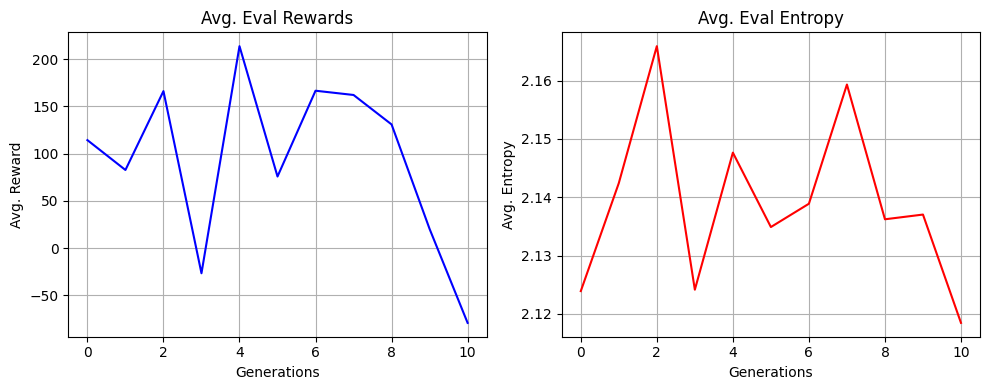

In [212]:
import matplotlib.pyplot as plt
import numpy as np

generations = [i for i in range(len(average_eval_entropy))]

# Create a figure and two subplots arranged in 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

# Plot average rewards on the first subplot (ax1)
ax1.plot(generations, average_eval_reward, label="Avg. Eval Rewards", color="blue")
ax1.set_title('Avg. Eval Rewards')
ax1.set_xlabel('Generations')
ax1.set_ylabel('Avg. Reward')
ax1.grid(True)

# Plot average entropy on the second subplot (ax2)
ax2.plot(generations, average_eval_entropy, label="Avg. Eval Entropy", color="red")
ax2.set_title('Avg. Eval Entropy')
ax2.set_xlabel('Generations')
ax2.set_ylabel('Avg. Entropy')
ax2.grid(True)

# Adjust layout to prevent titles/labels from overlapping
plt.tight_layout()

# Display the plot
plt.show()